In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore, mode
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture
from brokenaxes import brokenaxes
from sklearn.cluster import KMeans

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
save_dir=os.path.join(later_dir,'temp_filter','figs')

In [3]:
for x in sorted(os.listdir(later_dir)):
    if 'dic' in x:
        print(x)

10flies_best_event_times_split_dic.pkl
10flies_event_times_split_dic.pkl
10flies_total_dict.pkl
best_event_times_split_dic.pkl
event_times_split_dic.pkl
fly_208_dic.pkl
fly_209_dic.pkl
fly_210_dic.pkl
fly_217_dic.pkl
fly_218_dic.pkl
fly_226_dic.pkl
fly_227_dic.pkl
fly_228_dic.pkl
fly_233_dic.pkl
fly_234_dic.pkl
fly_239_dic.pkl
fly_240_dic.pkl
fly_241_dic.pkl
fly_242_dic.pkl
fly_249_dic.pkl
fly_250_dic.pkl
total_dict.pkl


In [4]:
fly_num=['226','227','228','234','239','240','241','242','249','250']
redo=True

In [5]:
%%time
total_path = os.path.join(later_dir, '10flies_total_dict.pkl')
if os.path.exists(total_path)==False:
    print("Making total dict")
    total_data_dict = {}
    for x in sorted(os.listdir(later_dir)):
        fly_name= x[4:7]
        if fly_name in fly_num and 'fly' in x:
            print(x)
            temp_path = os.path.join(later_dir, x)
            with open(temp_path, 'rb') as file:
                dic = pickle.load(file)
                total_data_dict[fly_name] = dic
    with open(total_path, 'wb') as file:
        pickle.dump(total_data_dict, file)
else:
    print("Loading total dict")
    with open(total_path, 'rb') as file:
        total_data_dict = pickle.load(file)

Loading total dict
CPU times: user 746 ms, sys: 8.9 s, total: 9.65 s
Wall time: 32.9 s


In [6]:
print(total_data_dict.keys())
print(total_data_dict['250'].keys())

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['signals', 'timestamps', 'event_times', 'bins', 'behavior', 'cluster_labels'])


In [7]:
# print(total_data_dict['239']['behavior'][0])
np.shape(total_data_dict['239']['behavior'])

(199, 500)

In [8]:
# print(total_data_dict['239']['event_times'])
np.shape(total_data_dict['239']['event_times'])

(199,)

In [9]:
highest_events=[]
for key in total_data_dict:
    num_events=len(total_data_dict[key]['behavior'])
    highest_events.append(num_events)
    print(f'{key} has {num_events}')
least=np.min(highest_events)
least

226 has 198
227 has 198
228 has 197
234 has 198
239 has 199
240 has 199
241 has 198
242 has 198
249 has 198
250 has 199


197

In [10]:
%%time
total_behave_struct = {}
shape = least
for key in total_data_dict:
    total_behave_struct[key] = total_data_dict[key]['behavior'][:shape,:]
#             temp = struct['behavior']

CPU times: user 2 µs, sys: 10 µs, total: 12 µs
Wall time: 15.5 µs


In [11]:
print(total_behave_struct.keys())
print(np.shape(total_behave_struct['239']))

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
(197, 500)


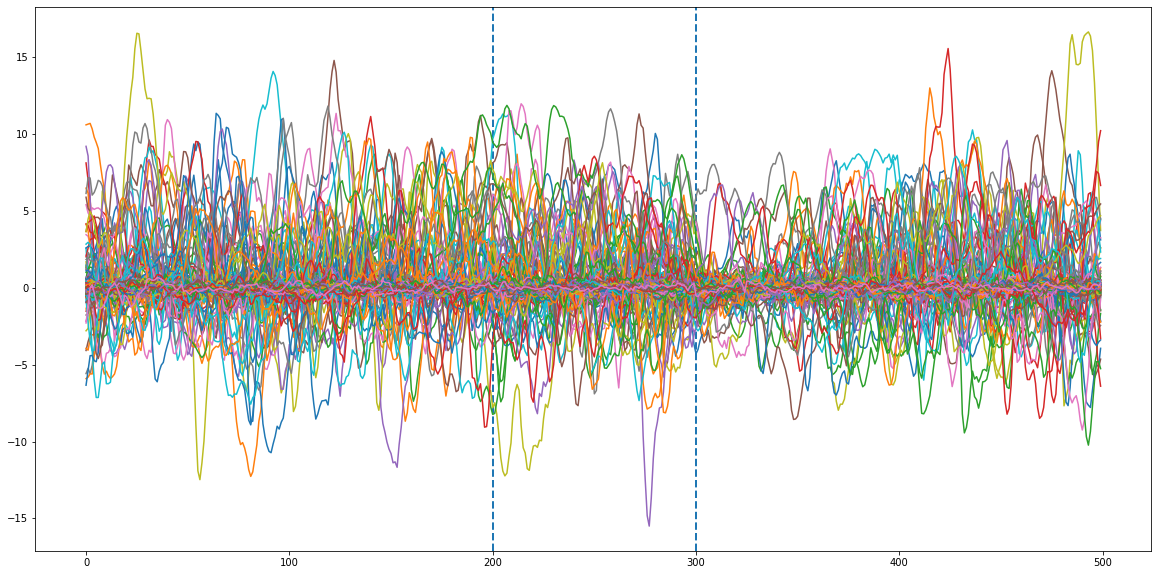

In [12]:
fig, ax = plt.subplots(figsize=(20,10))
ax.axvline(200, linewidth=2, linestyle='--')
ax.axvline(300, linewidth=2, linestyle='--')
# for key in total_behave_struct:
plt.plot(total_behave_struct['250'].T);

In [13]:
total=[]
for key in total_behave_struct:
    total.append(total_behave_struct[key])
total=np.vstack(total)

In [14]:
np.shape(total)

(1970, 500)

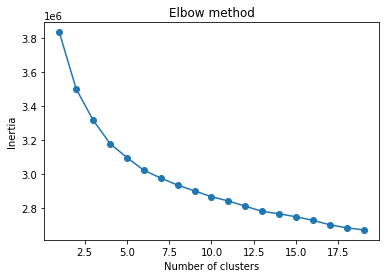

In [15]:
inertias = []
ks = 20

for i in range(1,ks):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(total)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,ks), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [16]:
n_clusters=3
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(total)
np.shape(kmeans.labels_)

(1970,)

Cluster 0 has 275 trials
Cluster 1 has 1381 trials
Cluster 2 has 314 trials


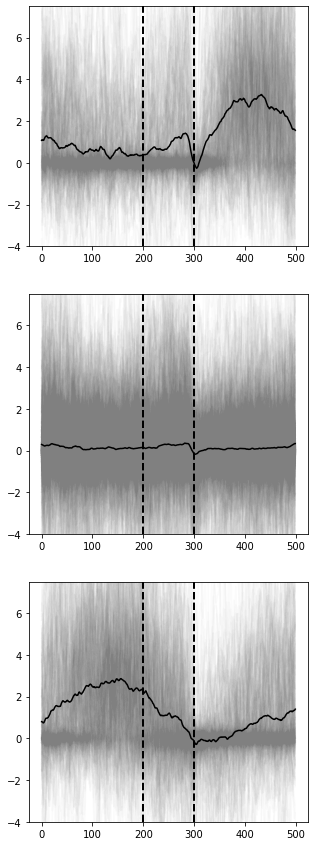

In [17]:
fig,axs=plt.subplots(nrows=n_clusters,ncols=1,figsize=(5,15))
labels=np.asarray(kmeans.labels_)
for i in range(n_clusters):
    axs[i].plot(total[labels==i].T, color='gray', alpha=0.03)
    axs[i].plot(np.mean(total[labels==i], axis=0).T, color='k')
    axs[i].axvline(200, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(300, linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-4, 7.5);
    print(f'Cluster {i} has {np.shape(total[labels==i])[0]} trials')
    

In [18]:
event_times_path=os.path.join(later_dir, 'best_event_times_split_dic.pkl')
with open(event_times_path, 'rb') as file:
    event_times_dic = pickle.load(file)
            

In [19]:
print(event_times_dic.keys())
print(event_times_dic['208'].keys())
event_times_dic['208']['flat']

dict_keys(['208', '209', '210', '217', '218', '226', '227', '228', '233', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat'])


[331650,
 354200,
 361620,
 421860,
 436730,
 450970,
 489110,
 519590,
 564110,
 571970,
 580310,
 587580,
 609990,
 616640,
 624440,
 678830,
 687170,
 710490,
 817590,
 825620,
 832270,
 977560,
 1208900,
 1223860,
 1254630,
 1262920,
 1466160,
 1618290,
 1626120,
 1738940,
 1768140]

In [20]:
test=event_times_dic['208']['inc'][0]
for trial in event_times_dic['208']['dec']:
    if test==trial:
        print(trial)

In [21]:
pre_window = 200
post_window = 300
# avg_around = 20
stim_time = 100

In [22]:
def vals_pre_post(loom, dist_loom, val_a, val_b, total_behave_struct, mean=True):
    pre_stim_total=[]
    post_stim_total=[]
    loom_a=loom-dist_loom
    loom_b=loom+dist_loom
    for fly in total_behave_struct:
        for trial in total_behave_struct[fly]:
            if mean:
                pre_stim=np.mean(trial[val_a:loom_a])
                pre_stim_total.append(pre_stim)
                post_stim=np.mean(trial[loom_b:val_b])
                post_stim_total.append(post_stim)
            else:
                pre_stim=trial[val_a:loom_a]
                pre_stim_total.append(pre_stim)
                post_stim=trial[loom_b:val_b]
                post_stim_total.append(post_stim)
    return pre_stim_total, post_stim_total

(1970,)


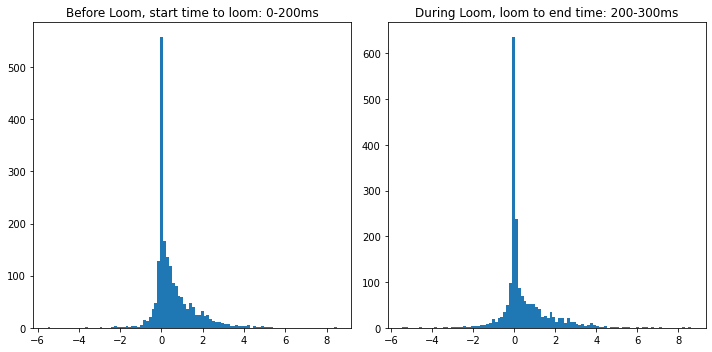

CPU times: user 487 ms, sys: 181 ms, total: 668 ms
Wall time: 475 ms


In [23]:
%%time

loom=200
# 100ms before and after loom
dist_loom, val_a, val_b=0,0,300
pre_stim_0_100ms, post_stim_0_100ms=vals_pre_post(loom, dist_loom, val_a, val_b, total_behave_struct)
print(np.shape(pre_stim_0_100ms))

n_bins=100
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axs[0].hist(pre_stim_0_100ms, n_bins)
# axs[0].plot(filterd_behave)
axs[0].set_title(f'Before Loom, start time to loom: {val_a}-{loom-dist_loom}ms')
axs[1].hist(post_stim_0_100ms, n_bins)
axs[1].set_title(f'During Loom, loom to end time: {loom+dist_loom}-{val_b}ms')
fig.tight_layout()
plt.show()

In [24]:
loom=200
# 100ms before and after loom
dist_loom, val_a, val_b=0,100,300
pre, post=vals_pre_post(loom, dist_loom, val_a, val_b, total_behave_struct, mean=True)
print(np.shape(pre))

(1970,)


1.9553033417964485

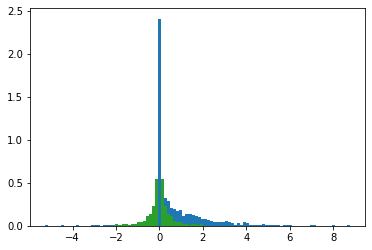

In [25]:
n_bins=100
hist, bin_edges = np.histogram(pre,n_bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:])/2
plt.bar(bin_centers,hist,width=bin_centers[1]-bin_centers[0])

negative_mask = (bin_centers <= 0) & (bin_centers>-2)
negative_bins = bin_centers[negative_mask]
negative_counts = hist[negative_mask]
plt.bar(negative_bins,negative_counts,width=bin_centers[1]-bin_centers[0])

mirrored_bins = np.concatenate([negative_bins, -negative_bins[::-1]])
mirrored_counts = np.concatenate([negative_counts, negative_counts[::-1]])
plt.bar(mirrored_bins,mirrored_counts,width=bin_centers[1]-bin_centers[0])
np.max(mirrored_bins)

In [26]:
hist, bin_edges = np.histogram(pre,n_bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:])/2

# Extract negative velocity data
negative_mask = (bin_centers <= 0) & (bin_centers > -2)
negative_bins = bin_centers[negative_mask]
negative_counts = hist[negative_mask]

# Mirror the negative values to positive side
mirrored_bins = np.concatenate([negative_bins, -negative_bins[::-1]])
mirrored_counts = np.concatenate([negative_counts, negative_counts[::-1]])

def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

# Initial guesses for parameters
p0 = [max(mirrored_counts), np.mean(mirrored_counts), np.std(mirrored_counts)]

# Fit the Gaussian
params, covariance = curve_fit(gaussian, mirrored_bins, mirrored_counts, p0=p0)
amplitude, mean, stddev = params
print(amplitude,mean,stddev)

# Generate the fitted Gaussian for all bins
fitted_gaussian = gaussian(bin_centers, amplitude, mean, stddev)

# Find where actual counts is inside the Gaussian fit
inside_mask = (hist <fitted_gaussian)


0.6090442746938601 1.0468189117390345e-06 0.22918136073433715


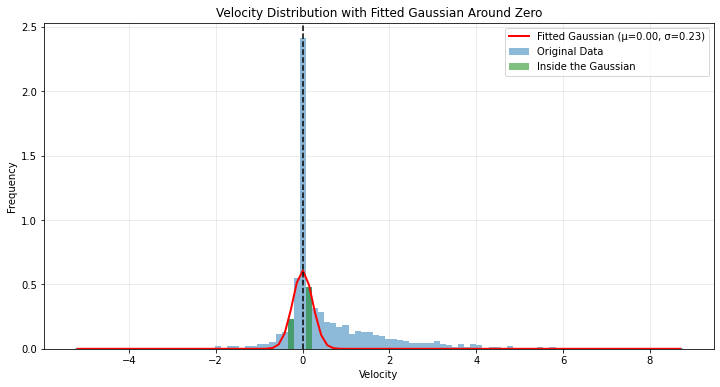

Velocities inside the Gaussian fit: [-5.03921774 -4.89903982 -4.75886189 -4.61868396 -4.33832811 -4.19815018
 -4.05797225 -3.91779433 -3.63743847 -3.49726054 -3.35708262 -3.21690469
 -2.65619298 -0.27316821  0.14736557  5.61430474  6.17501645  6.31519437
  6.4553723   6.59555023  6.73572816  6.87590608  7.29643987  7.43661779
  7.57679572  7.71697365  7.85715158  8.13750743  8.27768536  8.41786329
  8.55804121], max is 8.558041213419862, min is -0.27316821296183846


In [27]:
plt.figure(figsize=(12, 6))

# Plot original histogram
plt.bar(bin_centers, hist, width=bin_centers[1]-bin_centers[0], 
        alpha=0.5, label='Original Data')

# Plot fitted Gaussian
plt.plot(bin_centers, fitted_gaussian, 'r-', linewidth=2, 
        label=f'Fitted Gaussian (μ={mean:.2f}, σ={stddev:.2f})')

# Highlight excess velocities
plt.bar(bin_centers[inside_mask], hist[inside_mask], 
        width=bin_centers[1]-bin_centers[0], color='green', alpha=0.5, 
        label='Inside the Gaussian')

plt.axvline(x=0, color='k', linestyle='--')
plt.xlabel('Velocity')
plt.ylabel('Frequency')
plt.legend()
plt.title('Velocity Distribution with Fitted Gaussian Around Zero')
plt.grid(alpha=0.3)
plt.show()

# Extract the values within the gaussian 
inside_velocities = bin_centers[inside_mask]
max_zero=np.max(inside_velocities)
min_zero=np.min(inside_velocities[inside_velocities>-2])
print(f"Velocities inside the Gaussian fit: {inside_velocities}, max is {max_zero}, min is {min_zero}")

In [28]:
gm = GaussianMixture(n_components=2, random_state=0).fit(np.asarray(pre).reshape(-1, 1))
labels= gm.predict(np.asarray(pre).reshape(-1, 1))

In [29]:
one = np.asarray(pre)[labels==1]
zero = np.asarray(pre)[labels==0]
# two = np.asarray(pre_stim_0_100ms)[labels==2]

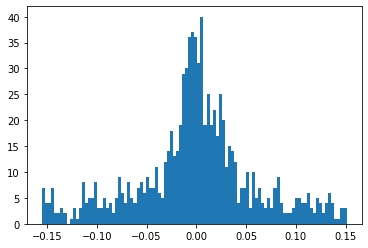

In [30]:
plt.hist(zero, n_bins);

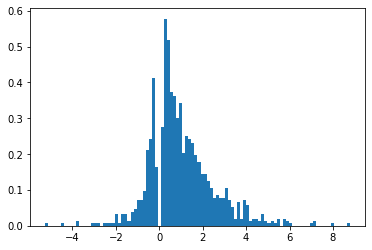

In [31]:
plt.hist(one, n_bins, density=True);

In [32]:
weird=one[one<np.min(zero)]

In [33]:
np.shape(weird)

(236,)

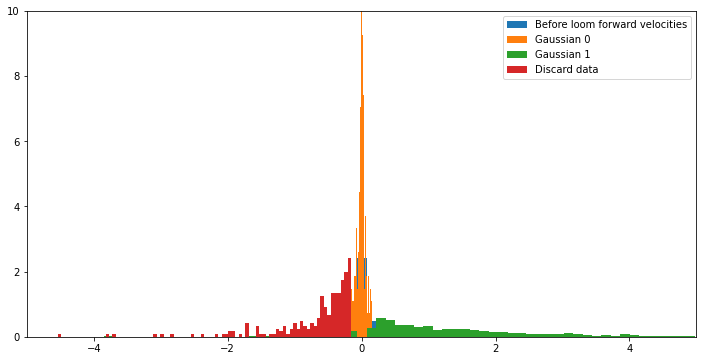

In [34]:
plt.figure(figsize=(12, 6))
plt.hist(pre, n_bins, density=True, label="Before loom forward velocities");
plt.hist(zero, n_bins, density=True,  label="Gaussian 0");
plt.hist(one, n_bins,  density=True,label="Gaussian 1");
plt.hist(weird, n_bins,  density=True,label="Discard data");
# plt.hist(two, n_bins, density=True);
plt.xlim(-5,5)
plt.ylim(0,10)
plt.legend()
# plt.bar(one)
# plt.bar(zero)

In [35]:
print(gm.means_)
print(gm.covariances_)

[[-3.64605031e-04]
 [ 9.58541341e-01]]
[[[0.00391469]]

 [[2.16130526]]]


In [36]:
# mid_mean=gm.means_[0]
# mid_var=gm.covariances_[0]
# cutoff=mid_var*3
# max_zero=mid_mean+cutoff
# min_zero=mid_mean-cutoff
max_zero=np.max(zero)
min_zero=np.min(zero)

In [37]:
print(min_zero, max_zero)
print(np.min(zero), np.max(zero))

-0.15489765418345836 0.15101806891187095
-0.15489765418345836 0.15101806891187095


In [38]:
loom=200
from_loom=200
splits={'moving':[],'non_moving':[], 'weird':[]}
for key in total_behave_struct:
    fly=total_behave_struct[key]
    for trial in fly:
        pre_stim=np.mean(trial[loom-from_loom:loom])
        if pre_stim>-2:
            if pre_stim>max_zero:
                splits['moving'].append(trial)
            elif pre_stim<=max_zero and pre_stim >=min_zero:
                splits['non_moving'].append(trial)
            else:
                splits['weird'].append(trial)
mov=np.shape(splits['moving'])
still=np.shape(splits['non_moving'])
weird=np.shape(splits['weird'])
print(f'Moving trials count: {mov[0]}, stopped trials count: {still[0]}, weird trials count: {weird[0]}')

Moving trials count: 1027, stopped trials count: 750, weird trials count: 185


In [39]:
def plot_trace(behavior_trace, pre_window, post_window, stim_time):
    mean_trace = np.mean(behavior_trace, axis=0)
    sem_trace = scipy.stats.sem(behavior_trace, axis=0)
    
    plt.figure(figsize=(10,10))
    plt.plot(mean_trace,color='k',linewidth=3)
    plt.fill_between(np.arange(len(mean_trace)),mean_trace-sem_trace, mean_trace+sem_trace, color='k',alpha=0.3)
    plt.axvline(pre_window,color='k',linestyle='--',lw=2)
    plt.axvline(pre_window+stim_time,color='k',linestyle='--',lw=2)
    plt.ylim(-1.5, 3);

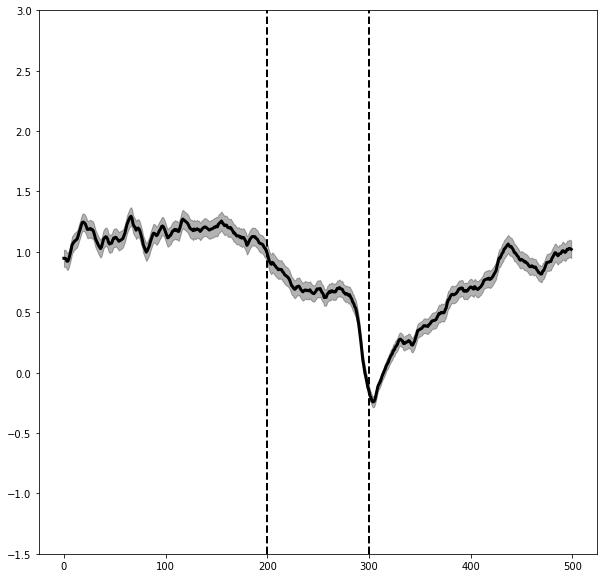

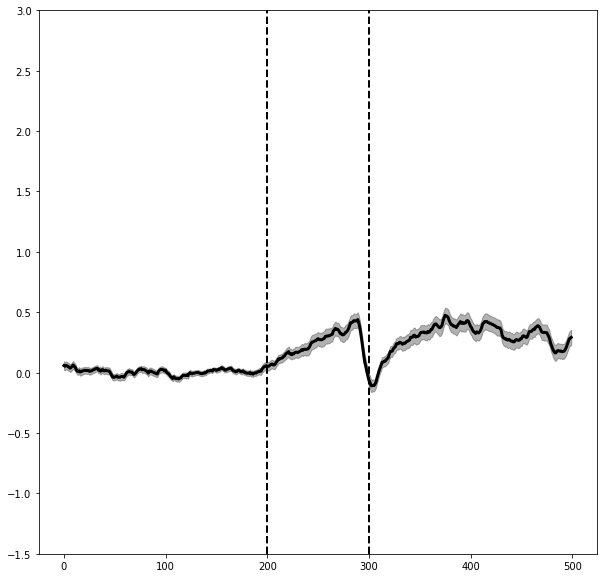

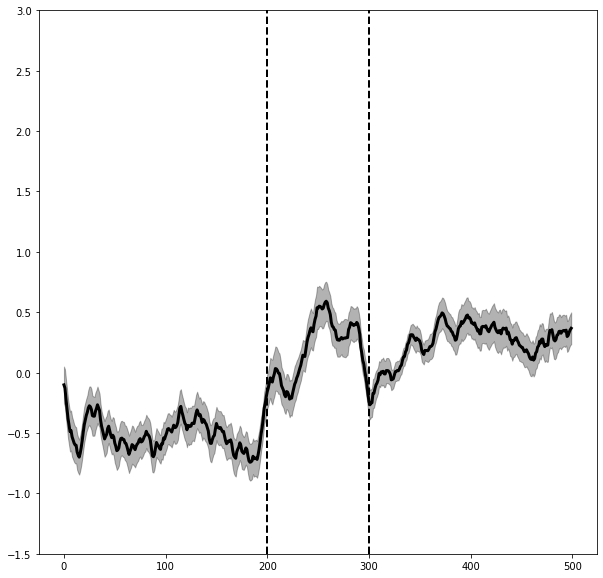

In [40]:
pre_window = 200
post_window = 300
# avg_around = 20
stim_time = 100
plot_trace(splits['moving'], pre_window, post_window, stim_time)
plot_trace(splits['non_moving'], pre_window, post_window, stim_time)
plot_trace(splits['weird'], pre_window, post_window, stim_time)

(1027, 500)
(1027,)
(1027,)
-0.6272292994414242


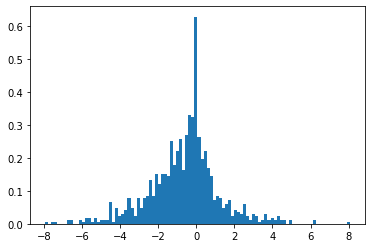

In [41]:
data=np.asarray(splits['moving'])
print(np.shape(data))

pre=np.mean(data[:,100:200],axis=-1)
print(np.shape(pre))
post=np.mean(data[:,250:300],axis=-1)
print(np.shape(post))
diff=post-pre
plt.hist(diff,n_bins, density=True);
print(np.mean(diff))

(750, 500)
(750,)
(750,)
0.3063811610385938


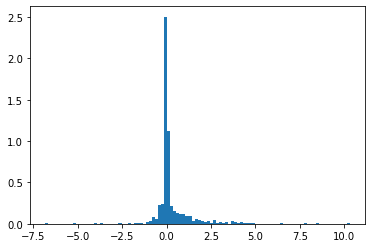

In [42]:
loom=200
data=np.asarray(splits['non_moving'])
print(np.shape(data))

pre=np.mean(data[:,100:200],axis=-1)
print(np.shape(pre))
post=np.mean(data[:,250:300],axis=-1)
print(np.shape(post))
diff2=post-pre
plt.hist(diff2,n_bins, density=True);
print(np.mean(diff2))


(935, 500)
(935,)
(935,)
0.41429418076174607


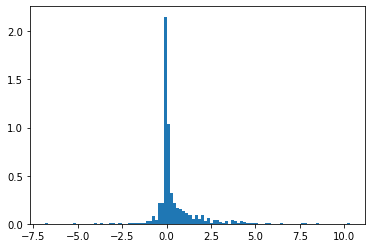

In [43]:
data_test=np.concatenate((splits['non_moving'],splits['weird']))
print(np.shape(data_test))

pre=np.mean(data_test[:,100:200],axis=-1)
print(np.shape(pre))
post=np.mean(data_test[:,250:300],axis=-1)
print(np.shape(post))
diff3=post-pre
plt.hist(diff3,n_bins, density=True);
print(np.mean(diff3))


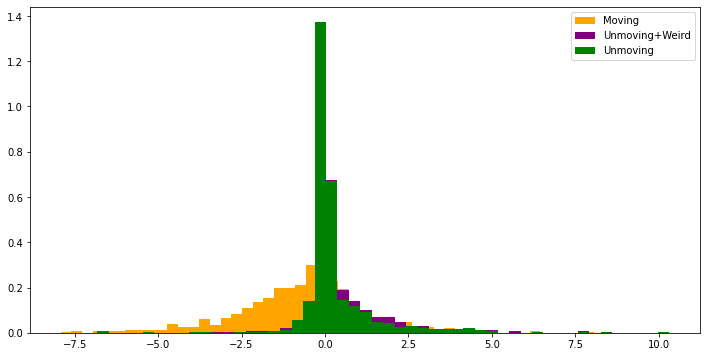

In [44]:
n_bins=50
plt.figure(figsize=(12, 6))
plt.hist(diff, n_bins, density=True, color='orange',label="Moving");
plt.hist(diff3, n_bins,  density=True,color='purple',label="Unmoving+Weird");
plt.hist(diff2, n_bins, density=True, color='g', label="Unmoving");

# plt.hist(two, n_bins, density=True);
# plt.xlim(-5,5)
# plt.ylim(0,10)
plt.legend()

In [45]:
data=np.asarray(diff3).reshape(-1, 1)
print(np.shape(data))
gm = GaussianMixture(n_components=2, random_state=0).fit(data)
labels= gm.predict(data)


(935, 1)


In [46]:
one = data[labels==1]
zero = data[labels==0]
# two = data[labels==2]

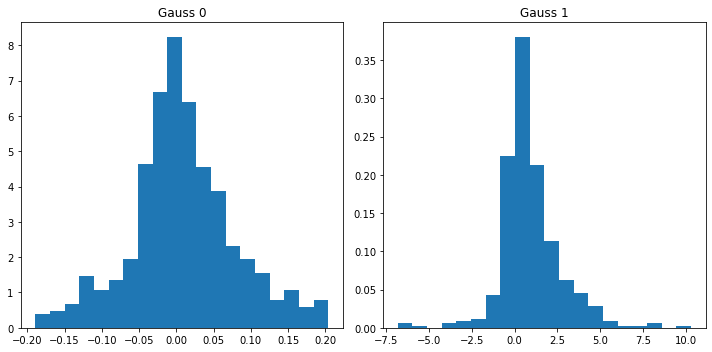

In [47]:
n_bins=20
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axs[0].hist(zero, n_bins, density=True)
# axs[0].plot(filterd_behave)
axs[0].set_title('Gauss 0')
axs[1].hist(one, n_bins,density=True)
axs[1].set_title('Gauss 1')
# axs[2].hist(two, n_bins,density=True)
# axs[2].set_title('Gauss 2')
fig.tight_layout()
plt.show()

In [48]:
splits.keys()

dict_keys(['moving', 'non_moving', 'weird'])

In [49]:
compare={}
for key in splits:
    data=splits[key]
    compare[key]={'pre':[], 'post': []}
    for trial in data:
    #     print(np.shape(trial))
        pre=np.mean(trial[100:200])
        compare[key]['pre'].append(pre)
        post=np.mean(trial[250:300])
        compare[key]['post'].append(post)
    print(f'{key}: Shape pre: {np.shape(compare[key]["pre"])}, Shape post: {np.shape(compare[key]["post"])}')

moving: Shape pre: (1027,), Shape post: (1027,)
non_moving: Shape pre: (750,), Shape post: (750,)
weird: Shape pre: (185,), Shape post: (185,)


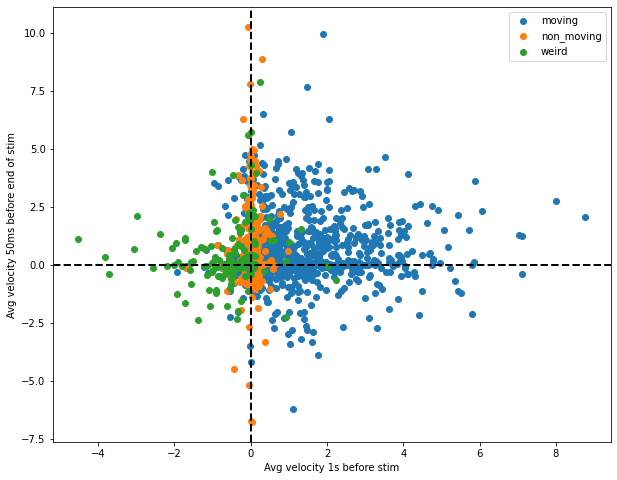

In [50]:
plt.figure(figsize=(10, 8))
for key in compare:
     plt.scatter(compare[key]['pre'], compare[key]['post'], label=key);   
plt.axvline(0,color='k',linestyle='--',lw=2)
plt.axhline(0,color='k',linestyle='--',lw=2)
plt.xlabel('Avg velocity 1s before stim')
plt.ylabel('Avg velocity 50ms before end of stim')
plt.legend()   

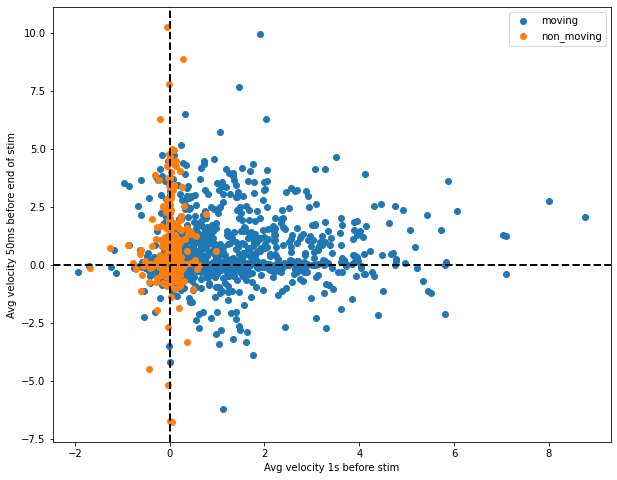

In [51]:
plt.figure(figsize=(10, 8))
for key in compare:
    if key != 'weird':
        plt.scatter(compare[key]['pre'], compare[key]['post'], label=key);
plt.axvline(0,color='k',linestyle='--',lw=2)
plt.axhline(0,color='k',linestyle='--',lw=2)
# plt.axvline(non_moving_thresh,color='r',linestyle='--',lw=2)
# plt.axhline(1,color='r',linestyle='--',lw=2)
# plt.axhline(-1,color='r',linestyle='--',lw=2)
plt.xlabel('Avg velocity 1s before stim')
plt.ylabel('Avg velocity 50ms before end of stim')
plt.legend()   

In [52]:
# trial_split={'dec':[],
#            'inc':[],
#            'flat':[],
#           }
# for trial in total:
#     pre=np.mean(trial[:200])
#     post=np.mean(trial[250:300])
#     if pre>-2 and post>-5:
#         if pre<=0.01:
#             if post>=-0.5 and post<=0.1:
#                 trial_split['flat'].append(trial)
#             elif post>0.1:
#                 trial_split['inc'].append(trial)
#             else:
#                 trial_split['dec'].append(trial)
#         else:
#             if post<=pre+0.01 and post>=pre-0.01:
#                 trial_split['flat'].append(trial)
#             elif post<pre:
#                 trial_split['dec'].append(trial)
#             elif post>0 and post>pre:
#                 trial_split['inc'].append(trial)

In [53]:
best_event_times_dic={}
best_trials={'inc':[],'dec':[],'flat':[]}
best_behavior={'total':[],'dec':[],'inc':[],'flat':[]}
for fly in total_data_dict:
    best_event_times_dic[fly]={'inc':[],'dec':[],'flat':[]}
    fly_behavior=total_data_dict[fly]['behavior']
    looms=total_data_dict[fly]['event_times']
    for i,trial in enumerate(fly_behavior):
    #     print(np.shape(trial))
        pre=np.mean(trial[:200])
        post=np.mean(trial[250:300])
        best_behavior['total'].append([pre, post])
        if pre<=0.1 and pre>-0.1:
            if post>=-0.1 and post<=0.1:
                best_event_times_dic[fly]['flat'].append(looms[i])
                best_trials['flat'].append(fly_behavior[i])
                best_behavior['flat'].append([pre, post])
            elif post>np.abs(pre*10):
                best_event_times_dic[fly]['inc'].append(looms[i])
                best_trials['inc'].append(fly_behavior[i])
                best_behavior['inc'].append([pre, post])
        if pre>1:
#             if post<=pre+0.1 and post>=pre-0.1:
#                 best_event_times_dic[fly]['flat'].append(looms[i])
#                 best_trials['flat'].append(fly_behavior[i])
#                 best_behavior['flat'].append([pre, post])
            if post>=-0.1 and post<pre/5:
                best_event_times_dic[fly]['dec'].append(looms[i])
                best_trials['dec'].append(fly_behavior[i])
                best_behavior['dec'].append([pre, post])

In [54]:
trial_set=best_behavior
# behave='flat'
count=0
for key in trial_set:
    num=np.shape(trial_set[key])
    print(f'{key} has {num[0]} trials')
    if key != 'total':
        count+=num[0]
print(count)

total has 1982 trials
dec has 132 trials
inc has 126 trials
flat has 416 trials
674


In [55]:
# best_events_path = os.path.join(later_dir, '10flies_best_event_times_split_dic.pkl')

# with open(best_events_path, 'wb') as file:
#     pickle.dump(best_event_times_dic, file)

In [56]:
print(best_event_times_dic.keys())
print(best_event_times_dic['250'].keys())
print(np.shape(best_event_times_dic['250']['inc']))

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat'])
(15,)


In [153]:
inc_b=np.asarray(best_behavior['inc'])[:,0]
flat_b=np.asarray(best_behavior['flat'])[:,0]
idx_vals_pre=[]
for val in inc_b:
    idx=(np.abs(flat_b - val)).argmin()
#     print(idx)
    idx_vals_pre.append(idx)
    flat_b[idx]=100

In [160]:
dec_a=np.asarray(best_behavior['dec'])[:,1]
flat_a=np.asarray(best_behavior['flat'])[:,1]
idx_vals_post=[]
for val in dec_a:
    idx=(np.abs(flat_a - val)).argmin()
#     print(idx)
    idx_vals_post.append(idx)
    flat_a[idx]=-100

In [173]:
looms_inc=[]
looms_dec=[]
looms_flat=[]
for fly in best_event_times_dic:
    for b in best_event_times_dic[fly]:
        if b=='flat':
            looms_flat.append(best_event_times_dic[fly][b])
#             print(np.shape(looms_flat))
        elif b=='inc':
            looms_inc.append(best_event_times_dic[fly][b])
        elif b=='dec':
            looms_dec.append(best_event_times_dic[fly][b])
looms_inc=np.hstack(looms_inc)
looms_dec=np.hstack(looms_dec)
looms_flat=np.hstack(looms_flat)

In [174]:
print(np.shape(idx_vals_pre))
print(np.shape(looms_inc))
print(np.shape(idx_vals_post))
print(np.shape(looms_dec))

(126,)
(126,)
(132,)
(132,)


In [191]:
total_idx=np.unique(np.concatenate((idx_vals_pre, idx_vals_post), axis=0))
looms_flat_pre=looms_flat[idx_vals_pre]
looms_flat_post=looms_flat[idx_vals_post]
total_loom_flat=np.concatenate((looms_flat_pre, looms_flat_post), axis=0)
print(np.shape(total_loom_flat))
total_loom_flat_final=np.unique(total_loom_flat)
print(np.shape(total_loom_flat_final))

(258,)
(221,)


In [196]:
s = np.sort(total_loom_flat, axis=None)
final_repeats=s[:-1][s[1:] == s[:-1]]
print(np.shape(np.unique(final_repeats)))

(37,)


In [200]:
rand_idxs=np.random.randint(100,size=100)
loom_rand=total_loom_flat_final[rand_idxs]
final_flat=np.concatenate((final_repeats,loom_rand))
print(np.shape(final_flat))

(137,)


In [202]:
total_data_dict['250'].keys()

dict_keys(['signals', 'timestamps', 'event_times', 'bins', 'behavior', 'cluster_labels'])

In [260]:
flat_events={}
flat_behavior={}
count=0
for fly in total_data_dict:
    flat_events[fly]={'flat':[]}
    flat_behavior={'flat':[]}
    for event in final_flat:
        if event in total_data_dict[fly]['event_times']:
            i=np.where(event==total_data_dict[fly]['event_times'])
            b=total_data_dict[fly]['behavior'][i]
            pre=b[:,:200]
#             print(np.min(pre))
            if np.max(pre)<5 and np.min(pre)>-3:
                flat_behavior['flat'].append(b)
                flat_events[fly]['flat'].append(event)
                count+=1
flat_behavior['flat']=np.vstack(flat_behavior['flat'])
print(count)

127


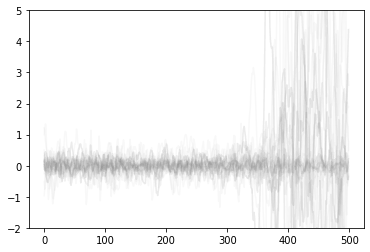

In [261]:
plt.plot(flat_behavior['flat'].T,color='gray', alpha=0.05);
plt.ylim(-2,5);

In [ ]:
flat_events_path = os.path.join(later_dir, 'flat_event_times_split_dic.pkl')

with open(best_events_path, 'wb') as file:
    pickle.dump(best_event_times_dic, file)

In [57]:
colors={
    'inc': '#A2142F',
    'dec': '#727272',
    'flat': 'w'
}

In [58]:
def plot_multi_trace(behavior_trace, pre_window, post_window, stim_time, ax=None, color='k'):
    mean_trace = np.mean(behavior_trace, axis=0)
    if ax!=None:
        axs[ax].plot(np.asarray(behavior_trace).T,color='gray', alpha=0.05)
        axs[ax].plot(mean_trace,color=color,linewidth=3)
        axs[ax].axvline(pre_window,color='k',linestyle='--',lw=2)
        axs[ax].axvline(pre_window+stim_time,color='k',linestyle='--',lw=2)
        axs[ax].set_ylim(-2,5);
    else:
        axs.plot(np.asarray(behavior_trace).T,color='gray', alpha=0.05)
        axs.plot(mean_trace,color=color,linewidth=3)
        axs.axvline(pre_window,color='k',linestyle='--',lw=2)
        axs.axvline(pre_window+stim_time,color='k',linestyle='--',lw=2)
        axs.set_ylim(-3,6);

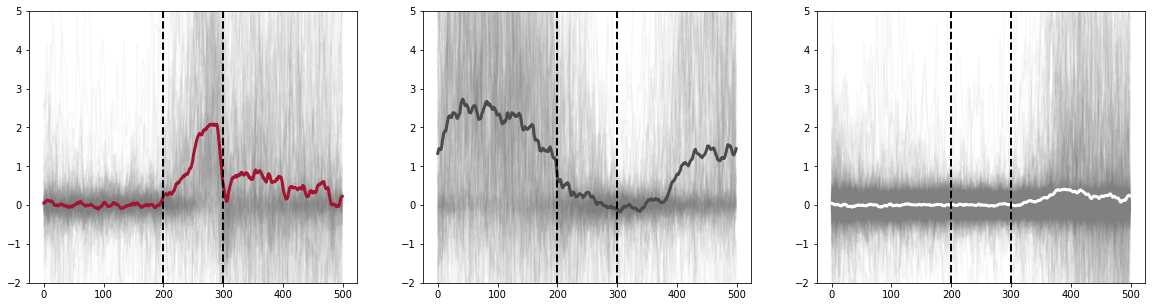

In [59]:
trial_set=best_trials
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,5))
plot_multi_trace(trial_set['inc'], pre_window, post_window, stim_time, 0, color=colors['inc'])
plot_multi_trace(trial_set['dec'], pre_window, post_window, stim_time, 1, color='#4b4b4b')
plot_multi_trace(trial_set['flat'], pre_window, post_window, stim_time, 2, color=colors['flat'])
# plt.savefig(os.path.join(save_dir,'best_avg_traces.png'), dpi=300, bbox_inches='tight')

In [60]:
i=np.shape(trial_set['inc'])[0]
d=np.shape(trial_set['dec'])[0]
f=np.shape(trial_set['flat'])[0]
t=i+d+f

print(f'inc {i} dec {d} flat {f} total {t}')

inc 126 dec 132 flat 416 total 674


In [61]:
best_behavior.keys()

dict_keys(['total', 'dec', 'inc', 'flat'])

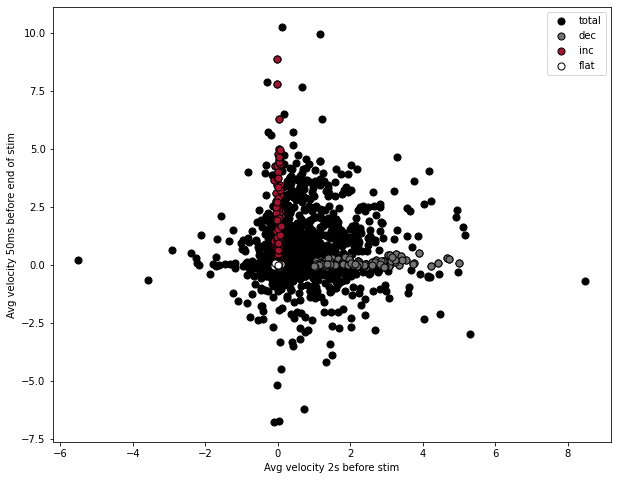

In [62]:
plt.figure(figsize=(10, 8))
# plt.scatter(total_pre, total_post);
behavior_set=best_behavior
for key in behavior_set:
#     print(key)
    if key!='total':
        plt.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=50,color=colors[key], edgecolor='k', label=key);
    else:
        plt.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=50, color='k', label=key);
# plt.axvline(0,color='k',linestyle='--',lw=2);
# plt.axhline(0,color='k',linestyle='--',lw=2);
plt.legend();
plt.xlabel('Avg velocity 2s before stim');
plt.ylabel('Avg velocity 50ms before end of stim');
# plt.savefig(os.path.join(save_dir,'best_avg_scatter.png'), dpi=300, bbox_inches='tight')

In [63]:
types={'inc':[], 'dec': [], 'flat':[]}
data=np.asarray(data_test)
for trial in data:
#     print(np.shape(trial))
    pre=np.mean(trial[100:200])
    post=np.mean(trial[250:300])
    change=post-pre
    if (change<np.max(zero)) & (change>np.min(zero)):
        types['flat'].append(trial)
    elif change>np.max(zero):
        types['inc'].append(trial)
    else:
        types['dec'].append(trial)
print(f'Num inc: {np.shape(types["inc"])[0]}, Num dec: {np.shape(types["dec"])[0]}, Num flat: {np.shape(types["flat"])[0]}')

Num inc: 305, Num dec: 108, Num flat: 522


In [64]:
np.shape(total_behave_struct['250'])

(197, 500)

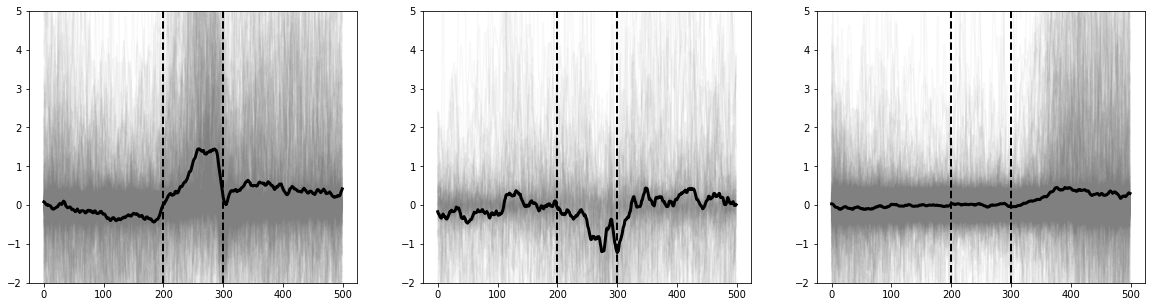

In [65]:
pre_window = 200
post_window = 300
# avg_around = 20
stim_time = 100
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,5))
plot_multi_trace(types["inc"], pre_window, post_window, stim_time, 0)
plot_multi_trace(types["dec"], pre_window, post_window, stim_time, 1)
plot_multi_trace(types["flat"], pre_window, post_window, stim_time, 2)

In [66]:
unmoving=np.asarray(diff2)
# gm = GaussianMixture(n_components=2, random_state=0).fit(np.asarray(pre_stim_0_100ms).reshape(-1, 1))
# labels= gm.predict(np.asarray(pre_stim_0_100ms).reshape(-1, 1))
weird_still=np.asarray(diff3)
# gm = GaussianMixture(n_components=2, random_state=0).fit(np.asarray(pre_stim_0_100ms).reshape(-1, 1))
# labels= gm.predict(np.asarray(pre_stim_0_100ms).reshape(-1, 1))

In [67]:
pre_window = 200
post_window = 300
# avg_around = 20
stim_time = 100
value_struct ={
    # the data is in 10ms, use this value to get the index if i use seconds
    "tp_width_sec": 0.01,
    "trial_time_sec": 1,
    "before_stim_sec": pre_window/100,
    # time in seconds between end of pre trial window and the stimulus time. 
    # when set to zero, the pre trial window ends when the stimulus is presented
    "pre_trial_window_sec": 0.01,
    # size of window that pre trial speed is averaged over, seconds, window ends at stimulus time
    # when 0 is a single val and not a window
    "pre_trial_size_sec": 0.5,
    # size of post trial speed average window, sec
    "post_trial_window_sec": 0.5,
    # post trial window at stim tiem + post trail delay
    # when 0 is a single val and not a window
    "post_trial_size_sec": 0.5,
    "thresh": 0.05,
    "fr": 100.00033694743087 
    #frame rate
    }

In [68]:
#total
inc, dec, flat = brainsss.separate_traces(total_behave_struct, value_struct)
trial_types_dict={'inc':inc,
                 'dec':dec,
                 'flat':flat}

Increase trial number: 713
Decrease trial number: 904
Flat trial number: 353


In [69]:
trace_types_dict={'inc':[],
                 'dec':[],
                 'flat':[]}
count=0
for key in trial_types_dict:
    behavior=trial_types_dict[key]
#     print(behavior.keys())
    name=key
    for fly in behavior:
        trace_types_dict[key].append(behavior[fly]['traces'])
#     trace_types_dict[key]=np.asarray(trace_types_dict[key])
    trace_types_dict[key]=np.vstack(trace_types_dict[key])
    c=np.shape(trace_types_dict[key])[0]
    print(f'{key} has {c} trials')
    count+=c
print(f'total has {count} trials')

inc has 713 trials
dec has 904 trials
flat has 353 trials
total has 1970 trials


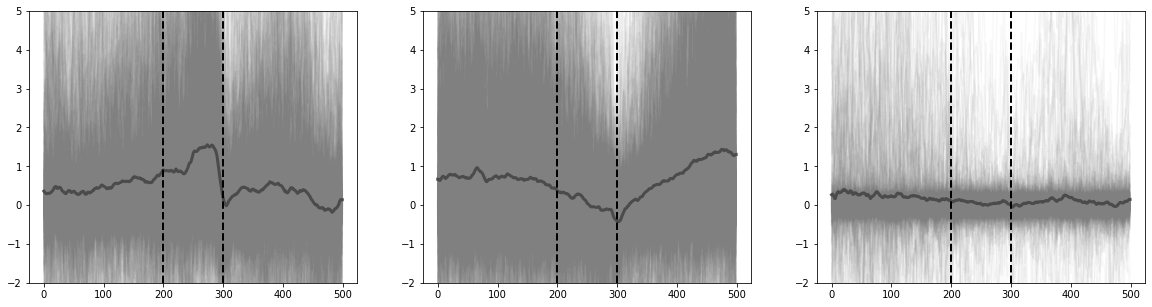

In [70]:
pre_window = 200
post_window = 300
# avg_around = 20
stim_time = 100
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,5))
plot_multi_trace(trace_types_dict['inc'], pre_window, post_window, stim_time, 0, color='#4b4b4b')#colors['inc']
plot_multi_trace(trace_types_dict['dec'], pre_window, post_window, stim_time, 1, color='#4b4b4b')##4b4b4b
plot_multi_trace(trace_types_dict['flat'], pre_window, post_window, stim_time, 2, color='#4b4b4b')#colors['flat']
# plt.savefig(os.path.join(save_dir,'total_avg_traces.png'), dpi=300, bbox_inches='tight')

In [71]:
%%time
in_order={}
trial_num=np.max(highest_events)
# print(trial_num)
for i in range(trial_num):
    in_order[i]={'inc':{},'dec':{}, 'flat':{}}
    for key in in_order[i]:
        in_order[i][key]={'traces':[], 'flies':[]}
for key in trial_types_dict:
    behavior=trial_types_dict[key]
    name=key
    for fly in behavior:
        traces=np.asarray(behavior[fly]['traces'])
        idxs=np.asarray(np.transpose(behavior[fly]['idx']))
        for i,val in enumerate(idxs):
            in_order[int(val)][name]['traces'].append(traces[i,:])
            in_order[int(val)][name]['flies'].append(fly)


CPU times: user 2.9 ms, sys: 0 ns, total: 2.9 ms
Wall time: 2.8 ms


In [72]:
bin_size=5
counts={'inc':np.zeros((int(len(in_order)/bin_size),3)),
       'dec':np.zeros((int(len(in_order)/bin_size),3)),
       'flat':np.zeros((int(len(in_order)/bin_size),3))}
for key in trial_types_dict:
    for i in range(0,len(in_order),bin_size):
        keys = range(i, i + bin_size)
        values = [len(in_order[k][key]['traces']) for k in keys if k in in_order]
        flies = [in_order[k][key]['flies'] for k in keys if k in in_order]
        flat_flies = [item for sublist in flies for item in sublist]
        fly, count=mode(flat_flies)
        idx=i//bin_size
        if idx<len(counts[key]):
            counts[key][idx,0]=sum(values)
            counts[key][idx,1]=fly
            counts[key][idx,2]=count
        

In [73]:
counts['flat'].shape

(39, 3)

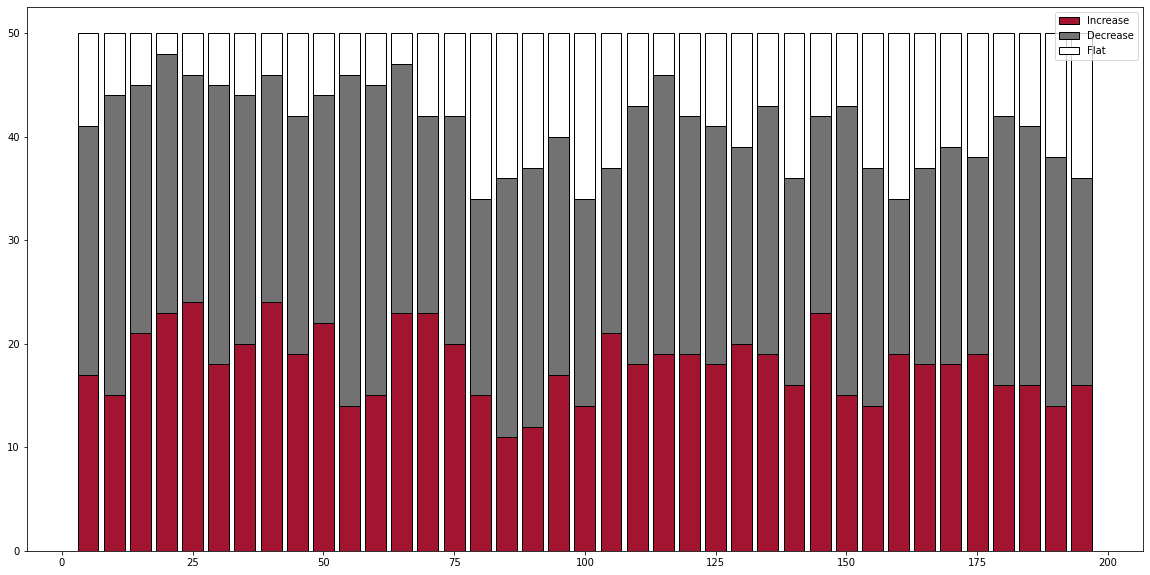

In [75]:
bin_end=np.arange(bin_size, len(in_order)+5, bin_size)[:-1]
width = 4

fig, ax = plt.subplots(figsize=(20,10))
bottom = np.zeros(len(bin_end))

for boolean, count in counts.items():
#     print(boolean,count[:,0])
    if boolean=='inc':
        lab='Increase'
    elif boolean=='dec':
        lab='Decrease'
    else:
        lab='Flat'
    p = ax.bar(bin_end, count[:,0], width, label=lab, bottom=bottom, color=colors.get(boolean, 'gray'), edgecolor='k')
    for i, (x, height, btm) in enumerate(zip(bin_end, count[:,0], bottom)):
        label1 = count[i, 1]
        label2 = count[i, 2]
        
#         # You can tweak the offset values here
#         ax.text(x, btm + height * 0.2, f'{int(label1)}', 
#                 ha='center', va='center', fontsize=8, color='k')
        
#         ax.text(x, btm + height * 0.1, f'{int(label2)}/{int(count[i, 0])}', 
#                 ha='center', va='center', fontsize=8, color='k')
    bottom += count[:,0]
    
# ax.set_title(f"{bin_size} trial count of trial type")
ax.legend(loc="upper right")

# plt.savefig(os.path.join(save_dir,'traces_type_bar.png'), dpi=300, bbox_inches='tight')

plt.show()

In [76]:
flies=list(total_data_dict.keys())

In [77]:
in_order[196]['dec']['flies']

['228', '239', '241']

In [78]:
trial_count_dict={}

for fly in flies:
    trial_count_dict[fly]=np.full(len(in_order), np.nan)
    for i in in_order:
        if fly in in_order[i]['flat']['flies']:
            trial_count_dict[fly][i]=0
#             print(f'fly {fly}, trial {i} fly is flat')
        elif fly in in_order[i]['dec']['flies']:
            trial_count_dict[fly][i]=-1
#             print(f'fly {fly}, trial {i} fly is dec')
        elif fly in in_order[i]['inc']['flies']:
            trial_count_dict[fly][i]=1
#             print(f'fly {fly}, trial {i} fly is inc')
        else:
            trial_count_dict[fly][i]=np.nan

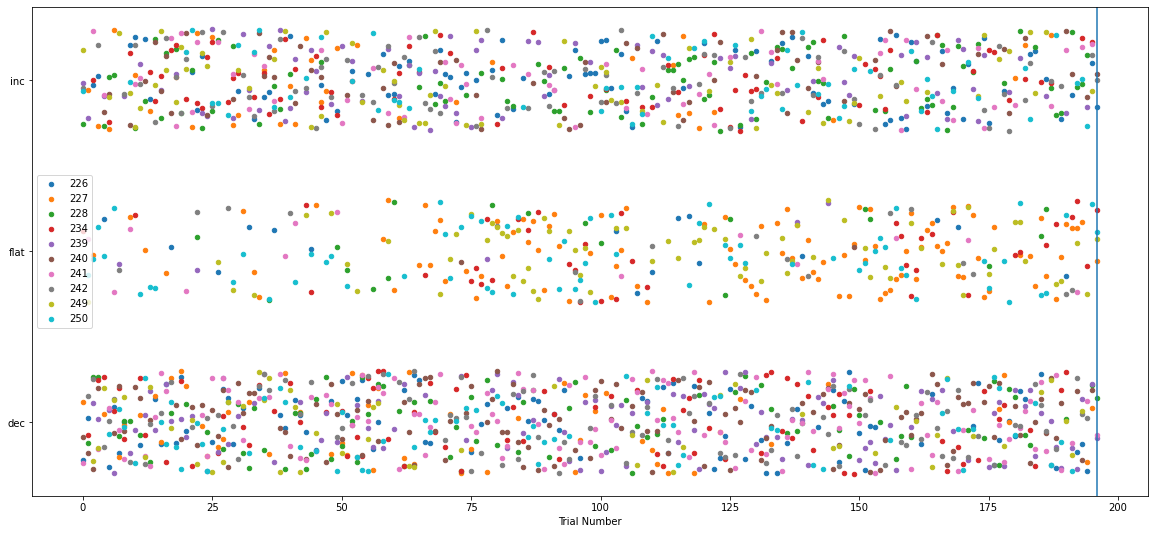

In [79]:
jitter_strength = 0.3
plt.figure(figsize=(20,9))
for key in trial_count_dict:
    vals=np.array(trial_count_dict[key]) + np.random.uniform(-jitter_strength, jitter_strength, size=len(trial_count_dict[key]))
    plt.scatter(np.asarray(list(in_order.keys())),vals, s=20, label=key);
#     plt.plot(trial_count_dict[key], marker='.', linestyle='' );
plt.yticks([1,0,-1],['inc', 'flat', 'dec']);
plt.legend();
plt.axvline(196)
plt.xlabel('Trial Number');

In [80]:
# plt.figure(figsize=(20,9))
# for key in trial_count_dict:
#     plt.imshow(trial_count_dict[key]);
trial_count_dict.keys()

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])

In [81]:
trial_count_lst=[]
for key in trial_count_dict:
    trial_count_lst.append(trial_count_dict[key])
trial_count_lst=np.asarray(trial_count_lst)
print(np.shape(trial_count_lst))

(10, 199)


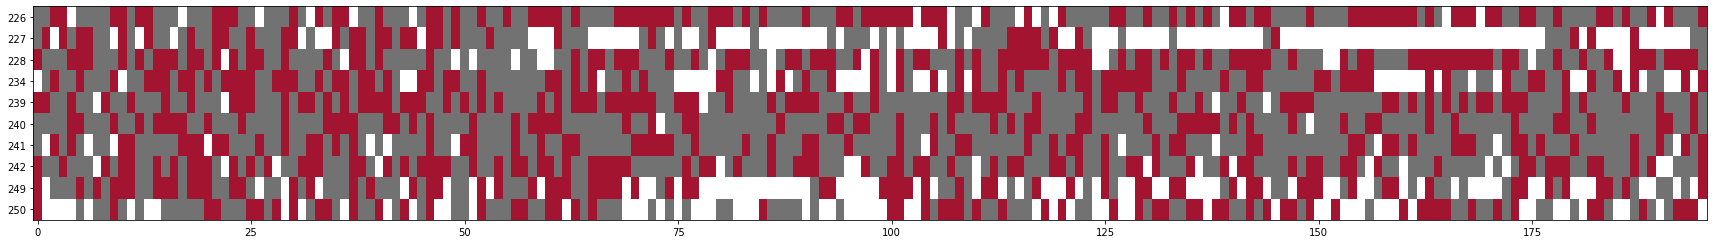

In [82]:
colors=['#727272', 'w', '#A2142F']
cmap=matplotlib.colors.ListedColormap(colors)

fig,axs=plt.subplots(figsize=(30,30))
im=axs.imshow(trial_count_lst[:,:196], cmap=cmap)
axs.set_yticks(np.arange(0,10));
axs.set_yticklabels(flies);
axs.set_aspect(2.5)
# cb=plt.colorbar(im)
# cb.set_ticks([-1,0,1])
# cb.set_ticklabels(['Dec', 'Flat', 'Inc'])
# plt.savefig(os.path.join(save_dir,'behave_type_raster.png'), dpi=300, bbox_inches='tight')

In [83]:
np.shape(trial_count_lst)

(10, 199)

In [84]:
# Initialize the results dictionary
repeats_sorted = {'-1': {}, '0': {}, '1': {}}

# Process each fly separately
for fly in range(np.shape(trial_count_lst)[0]):
    fly_data = trial_count_lst[fly, :]

    # Process continuous runs of the same value
    i = 0
    while i < len(fly_data):
        if np.isnan(fly_data[i]):
            i += 1
            continue

        # Get the current value
        val = fly_data[i]
        name = str(int(val))

        # Find the length of this run
        run_length = 1
        j = i + 1
        while j < len(fly_data) and fly_data[j] == val and not np.isnan(fly_data[j]):
            run_length += 1
            j += 1

        # Record this run in our results
        if run_length not in repeats_sorted[name]:
            repeats_sorted[name][run_length] = 0
        repeats_sorted[name][run_length] += 1

        # Skip ahead to the end of this run
        i = j

In [85]:
repeats_sorted

{'-1': {1: 215, 2: 120, 3: 59, 4: 31, 5: 10, 6: 7, 7: 3, 8: 2, 9: 1, 10: 1},
 '0': {1: 136, 2: 31, 3: 9, 4: 7, 5: 4, 6: 3, 8: 1, 10: 1, 13: 1, 31: 1},
 '1': {1: 270, 2: 108, 3: 30, 4: 17, 5: 4, 6: 4, 7: 1, 8: 1, 10: 1}}

In [86]:
%%time
repeats={}
for fly in range(np.shape(trial_count_lst)[0]):
    for i, val in enumerate(trial_count_lst[fly,:]):
    #     print(f'we are in the {i} spot')
        count=0
        if i!=0:
            idx=i
            while idx>0:
                if val==trial_count_lst[6,idx-1]:
                    count+=1
                    idx-=1
                else:
                    break
        try:
            repeats[count]['num']+=1
            repeats[count]['val'].append(val)
        except KeyError:
            repeats[count]={'num':0, 'val':[]}
            repeats[count]['num']=1
            repeats[count]['val'].append(val)

CPU times: user 1.9 ms, sys: 0 ns, total: 1.9 ms
Wall time: 1.9 ms


In [87]:
sorted_keys=np.sort(list(repeats.keys()))
sorted_repeats={i: repeats[i] for i in sorted_keys}
count_re=[sorted_repeats[key]['num'] for key in sorted_repeats]
most_common=[mode(sorted_repeats[key]['val'])[0][0] for key in sorted_repeats]

In [88]:
colors=[]
for val in most_common:
    if val>0:
        colors.append('#A2142F')
    elif val<0:
        colors.append('#727272')
    else:
        colors.append('w')

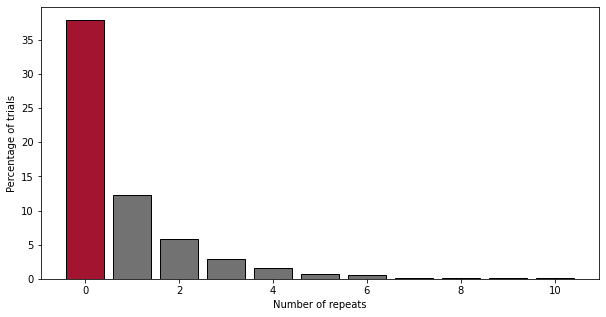

In [89]:
num_repeats=list(sorted_repeats.keys())
count_repeats=np.true_divide(count_re, (200*16))*100
plt.figure(figsize=(10,5))
plt.bar(num_repeats,count_repeats, color=colors, edgecolor='k');
plt.xlabel('Number of repeats');
plt.ylabel('Percentage of trials');

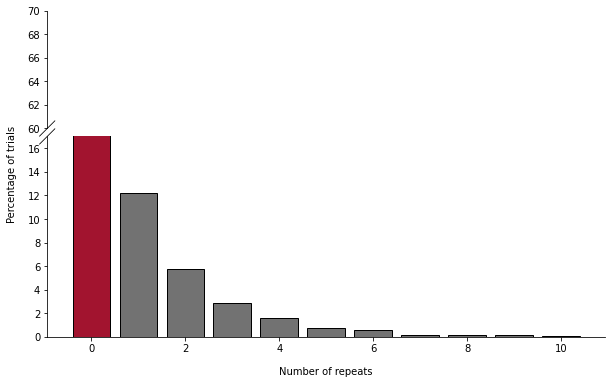

In [90]:

fig = plt.figure(figsize=(10,6))
bax = brokenaxes(ylims=((0, 17), (60, 70)), hspace=0.05)
bax.bar(num_repeats,count_repeats, color=colors, edgecolor='k')
bax.set_xlabel('Number of repeats', labelpad=15)
bax.set_ylabel('Percentage of trials', labelpad=30)

# Format y-ticks to integers
for ax in bax.axs:
    ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: int(x)))

plt.show()

In [91]:
colors={}
for val in repeats_sorted:
    if int(val)>0:
        colors[val]='#A2142F'
    elif int(val)<0:
        colors[val]='#727272'
    else:
        colors[val]='w'

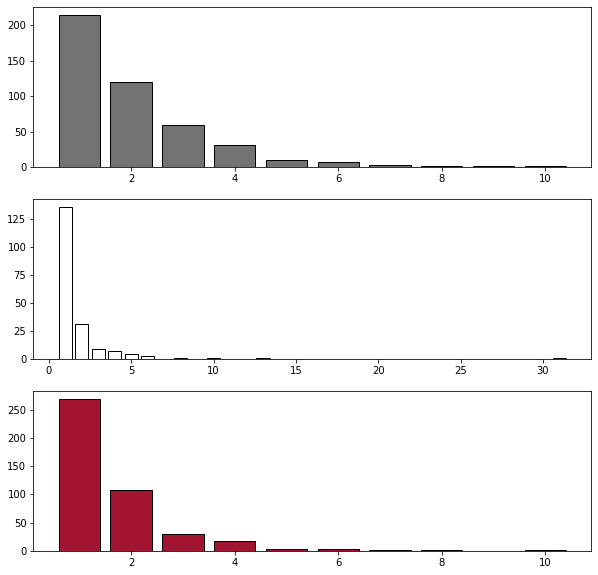

In [92]:
fig,axs = plt.subplots(nrows=3, ncols=1,figsize=(10,10))
ax_count=0

for behave in repeats_sorted:
    sorted_vals=[repeats_sorted[behave][key] for key in repeats_sorted[behave]]
#     percentage_vals=np.true_divide(sorted_vals, (200*16))*100
    keys=list(repeats_sorted[behave].keys())

    axs[ax_count].bar(keys,sorted_vals, color=colors[behave], edgecolor='k')
#     axs[ax_count].set_xlabel('Number of repeats', labelpad=15)
#     axs[ax_count].set_ylabel('Count of trials', labelpad=30)

    ax_count+=1
    # Format y-ticks to integers
#     for ax in bax.axs:
#         ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: int(x)))

# plt.savefig(os.path.join(save_dir,'hist_trial_type.png'), dpi=300, bbox_inches='tight')
plt.show()

In [93]:
event_times_total={}
for fly in total_data_dict:
    bool_inc = np.asarray(inc[fly]['idx'])[0]
    bool_dec = np.asarray(dec[fly]['idx'])[0]
    bool_flat = np.asarray(flat[fly]['idx'])[0]
    event_times = np.asarray(total_data_dict[fly]['event_times'])
    event_times_total[fly]={}
    event_times_total[fly]['total']=event_times
    event_times_total[fly]['inc']=event_times[bool_inc]
    event_times_total[fly]['dec']=event_times[bool_dec]
    event_times_total[fly]['flat']=event_times[bool_flat]

In [94]:
print(event_times_total.keys())
print(event_times_total['250'].keys())
np.shape(event_times_total['250']['total'])

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['total', 'inc', 'dec', 'flat'])


(199,)

In [95]:
event_times_total['250'].keys()

dict_keys(['total', 'inc', 'dec', 'flat'])

In [96]:
behavior='inc'
# idx = event_times_total['209'][behavior]

In [97]:
# idx = dect['250']['idx']
trace = total_data_dict['250']['behavior'][idx]

In [98]:
# fig1,ax1 = plot_trace(trace, pre_window, post_window, stim_time)

In [106]:
later_path = os.path.join(later_dir, '10flies_event_times_split_dic.pkl')

with open(later_path, 'wb') as file:
    pickle.dump(event_times_total, file)

In [ ]:
def overall_behavior_array(struct):
    temp = []
    for key in struct:
        try:
            lst = struct[key]['traces']
        except IndexError:
            lst = struct[key]
#         print(np.shape(lst))
        temp.append(lst)
    temp = np.vstack(temp)
#     print(np.shape(temp))
#     temp = np.mean(temp, axis=0)
    return np.asarray(temp)

In [ ]:
total = overall_behavior_array(total_behave_struct)

In [ ]:
def plotable_arrays(overall_behavior_array, inc, dec, flat):
    inc_lst = overall_behavior_array(inc)
    dec_lst = overall_behavior_array(dec)
    flat_lst = overall_behavior_array(flat)
    return inc_lst, dec_lst, flat_lst

In [ ]:
inc, dec, flat = plotable_arrays(overall_behavior_array,inct, dect, flatt)

In [ ]:
def plot_trace(behavior_trace, pre_window, post_window, stim_time, ax=None, fig=None):
    mean_trace = np.mean(behavior_trace, axis=0)
    sem_trace = scipy.stats.sem(behavior_trace, axis=0)
    color='b'
    
    if ax==None:
        fig, ax = plt.subplots(figsize=(10,10))
        color='k'
#     plt.figure(figsize=(10,10))
    ax.plot(mean_trace,color=color,linewidth=3)
    ax.fill_between(np.arange(np.shape(mean_trace)[0]),mean_trace-sem_trace, mean_trace+sem_trace, color='k',alpha=0.3)
    ax.axvline(pre_window,color='k',linestyle='--',lw=2)
    ax.axvline(pre_window+stim_time,color='k',linestyle='--',lw=2)
    ax.set_ylim(-0.5, 3.5);
    return fig, ax

In [ ]:
fig1,ax1 = plot_trace(dec, pre_window, post_window, stim_time)
# plot_trace(dec_n, pre_window, post_window, stim_time, ax=ax1)
print(np.shape(dec))
fig2,ax2 = plot_trace(inc, pre_window, post_window, stim_time)
# plot_trace(inc_n, pre_window, post_window, stim_time, ax=ax2)
print(np.shape(inc))
fig3,ax3 = plot_trace(flat, pre_window, post_window, stim_time)
# plot_trace(flat_n, pre_window, post_window, stim_time, ax=ax3)
print(np.shape(flat))